In [2]:
import sys
sys.path.append('../')
sys.path.append('../../')
import numpy as np
import matplotlib.pyplot as plt
import os

from DoseEngines import ModelConfig
from models import *
from models.utils.data import DataGenerator
from models.utils import *

/home/bolo/anaconda3/envs/autoplan/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:404: UserWarning: <built-in function array> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warn(
2025-06-02 12:58:20.278213: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-02 12:58:20.316470: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-02 12:58:20.317392: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025

In [3]:
if (os.path.exists('/mnt/')):
  data_path = '/media/bolo/f4616a95-e470-4c0f-a21e-a75a8d283b9e/DATASETS/ARTP/'
if (os.path.exists('/data/')):
  data_path = '/data/attila/matrad'
if (os.path.exists('/mimer/')):
  data_path = '/mimer/NOBACKUP/groups/naiss2023-6-64/matrad'

gen = DataGenerator(data_path, "training", False, 1)


Number of files: 2379 in training cohort


Displaying sample 6 / 2379 (MIQA_0334276fd9f_0_3.npz)


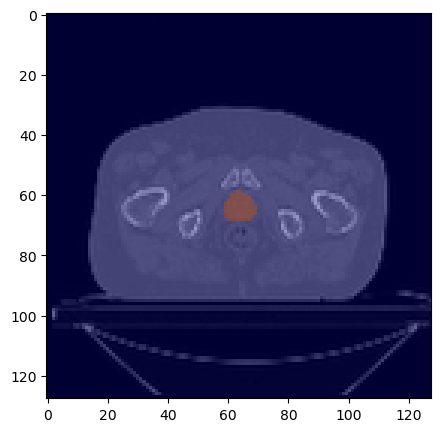

In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

for i, (x, y) in enumerate(gen):  # Loop through the generator
    clear_output(wait=True)  # Clear the previous image
    print(f"Displaying sample {i+1} / {len(gen)} ({gen.file_list[i]})")  # Print the current sample number
    
    plt.figure(figsize=(10, 5))

    # Gray image
    plt.imshow(x[0, :, :, 160, 0], cmap="gray")
    plt.imshow(x[0, :, :, 160, 1], cmap="jet", alpha=0.4)
    plt.show()
    
    time.sleep(0.1)  # Pause for 5 seconds before moving to the next one
    if i >= 5:  # Stop after displaying 10 samples
        break


(1, 128, 128, 320, 8) (1, 128, 128, 320)
-1.0 7.154539


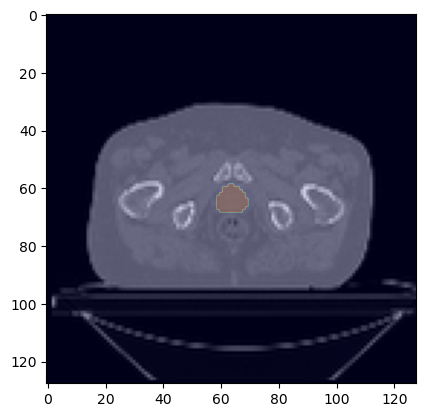

In [6]:
x, y = gen[0]
print(x.shape, y.shape)
print(np.min(x), np.max(x))

plt.imshow(x[0, :, :, 160, 0], cmap="gray")
plt.imshow(x[0, :, :, 160, 1], cmap="jet", alpha=0.2)

In [9]:
config = ModelConfig(ct_array_shape=(128, 128, 320), resolution=(0.2, 0.2, 0.2), downsampling_factor=(2, 2, 2), field_size=(3, 3), number_of_leaf_pairs=10, tpr_20_10=0.72, number_of_cps=3)
print(config)

TypeError: 'module' object is not callable

2025-03-11 15:07:43.406005: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


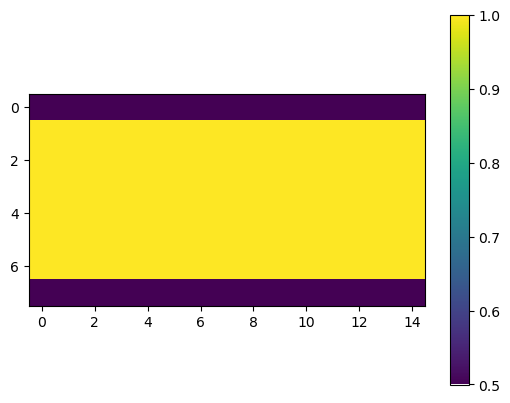

(3, 64, 64, 160, 1)


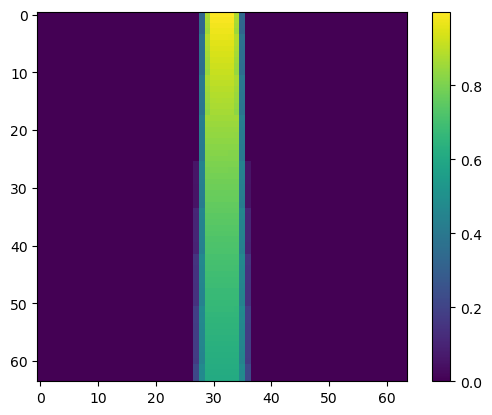

Depth: 0.0	width: 6.0
Depth: 4.0	width: 6.0
Depth: 8.0	width: 6.0
Depth: 12.0	width: 6.800000000000001
Depth: 16.0	width: 6.800000000000001
Depth: 20.0	width: 6.800000000000001
Depth: 24.0	width: 7.6000000000000005


In [ ]:
fluence_map_layer = FluenceMapLayer(config, slope=100.0)  # Instantiate the FluenceMapLayer
fluence_volume_layer = FluenceVolumeLayer(config)  # Instantiate the FluenceVolumeLayer with config

y_mlc = np.zeros((1, 2, config.number_of_cps, config.number_of_leaf_pairs))
y_mlc[:, 0, :, :] = 0.5
y_mlc[:, 1, :, :] = 1.0
fluence_map = fluence_map_layer(y_mlc)

plt.imshow(fluence_map[0, 0, :, :])
plt.colorbar()
plt.show()
fluence_volume = fluence_volume_layer(fluence_map)
print(np.shape(fluence_volume))
plt.imshow(fluence_volume[0, :, :, 80, 0], interpolation='none')
plt.colorbar()
plt.show()
for i in range(0, fluence_volume.shape[1], 10):
    print(f"Depth: {i * config.resolution[0]}\twidth: {np.sum(fluence_volume[0, i, 32, :, 0] > 0) * config.resolution[2]}")

In [ ]:
config.ct_array_shape

(64, 64, 160)

In [ ]:
y_mlc = np.zeros((2, 2, config.number_of_cps, config.number_of_leaf_pairs))
y_mlc[:, 0, :, :] = 0.5
y_mlc[:, 1, :, :] = 0.5
mus = np.array(0.1 * np.ones((2, config.number_of_cps)), dtype=np.float32)
dose_layer = AccumulateDose3DLayer(config, 45)
dose = dose_layer(x_ct, y_mlc, mus)

# print(np.unique(dose))

In [ ]:
np.argmax(np.sum(dose, (0, 1)))

20000

(2, 128, 128, 320)


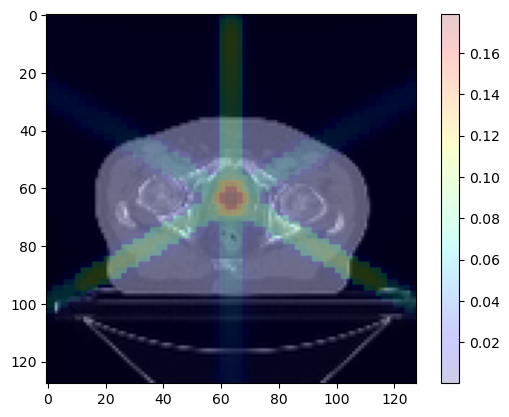

In [ ]:
print(dose.shape)

slice_idx = 160
plt.imshow(x_ct[1, :, :, slice_idx], cmap="gray")
plt.imshow(dose[0, :, :, slice_idx], cmap='jet', alpha=0.2)
plt.colorbar()
# plt.axis('off')
plt.show()

(2, 128, 128, 320)


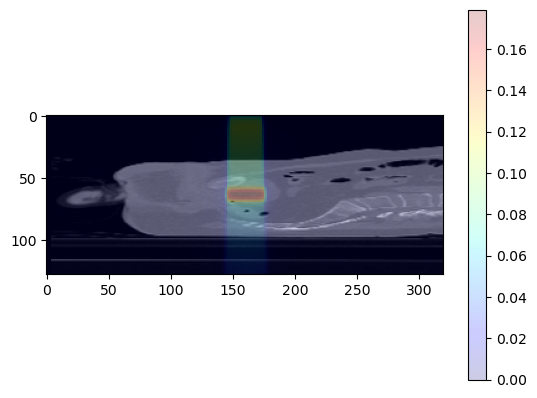

In [ ]:
print(dose.shape)

slice_idx = 160
plt.imshow(x_ct[1, :, 64, :], cmap="gray")
plt.imshow(dose[0, :, 64, :], cmap='jet', alpha=0.2)
plt.colorbar()
# plt.axis('off')
plt.show()